In [3]:
import requests
import os

print("Downloading NASA SRTM elevation data for Glasgow...")

# Bounding box for 5km around University of Strathclyde
min_lon = -4.35
min_lat = 55.82
max_lon = -4.15
max_lat = 55.92

# OpenTopography API
url = "https://portal.opentopography.org/API/globaldem"

params = {
    "demtype": "SRTMGL1",
    "south": min_lat,
    "north": max_lat,
    "west": min_lon,
    "east": max_lon,
    "outputFormat": "GTiff",
    "API_Key": "demoapikeyot2022"
}

response = requests.get(url, params=params)
print("Response status:", response.status_code)
print("Response size:", len(response.content), "bytes")

if response.status_code == 200:
    output_path = "/Users/riteshghorpade/Documents/010_Project/002_Dataset/nasa_srtm_glasgow.tif"
    with open(output_path, 'wb') as f:
        f.write(response.content)
    print("NASA SRTM data saved!")
else:
    print("Error:", response.text)

/Users/riteshghorpade/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Response status: 200
Response size: 139798 bytes
NASA SRTM data saved!


In [4]:
import rasterio
import numpy as np
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

# Open the NASA SRTM file
output_path = "/Users/riteshghorpade/Documents/010_Project/002_Dataset/nasa_srtm_glasgow.tif"

with rasterio.open(output_path) as src:
    print("NASA SRTM Data Info:")
    print("CRS:", src.crs)
    print("Resolution:", src.res, "degrees")
    print("Shape:", src.shape)
    print("Bounds:", src.bounds)
    
    # Read elevation values
    elevation_data = src.read(1)
    transform = src.transform
    
    print("\nElevation Stats:")
    print("Min elevation:", elevation_data.min(), "metres")
    print("Max elevation:", elevation_data.max(), "metres")
    print("Average elevation:", round(elevation_data.mean(), 2), "metres")
    print("Total data points:", elevation_data.size)

# Convert to GeoDataFrame
rows, cols = np.where(elevation_data > -9999)
elevations = elevation_data[rows, cols]

# Convert pixel coordinates to lat/lon
lons, lats = rasterio.transform.xy(transform, rows, cols)

# Create dataframe
nasa_df = pd.DataFrame({
    'latitude': lats,
    'longitude': lons,
    'elevation': elevations
})

# Convert to GeoDataFrame
nasa_gdf = gpd.GeoDataFrame(
    nasa_df,
    geometry=gpd.points_from_xy(nasa_df.longitude, nasa_df.latitude),
    crs="EPSG:4326"
)

# Convert to EPSG:27700 to match other datasets
nasa_gdf = nasa_gdf.to_crs("EPSG:27700")

print("\nNASA elevation GeoDataFrame:")
print("Total points:", len(nasa_gdf))
print(nasa_gdf.head())

# Save
nasa_gdf.to_file(
    "/Users/riteshghorpade/Documents/010_Project/002_Dataset/nasa_elevation_glasgow.gpkg",
    driver="GPKG"
)
print("\nNASA elevation data saved!")

NASA SRTM Data Info:
CRS: EPSG:4326
Resolution: (0.0002777777777778146, 0.0002777777777778146) degrees
Shape: (360, 720)
Bounds: BoundingBox(left=-4.350138888865615, bottom=55.82013888888834, right=-4.150138888865588, top=55.92013888888835)

Elevation Stats:
Min elevation: -23 metres
Max elevation: 132 metres
Average elevation: 41.59 metres
Total data points: 259200

NASA elevation GeoDataFrame:
Total points: 259200
   latitude  longitude  elevation                       geometry
0     55.92  -4.350000         79   POINT (253242.407 672152.61)
1     55.92  -4.349722         79   POINT (253259.762 672152.02)
2     55.92  -4.349444         79   POINT (253277.118 672151.43)
3     55.92  -4.349167         79   POINT (253294.473 672150.84)
4     55.92  -4.348889         78  POINT (253311.828 672150.251)

NASA elevation data saved!


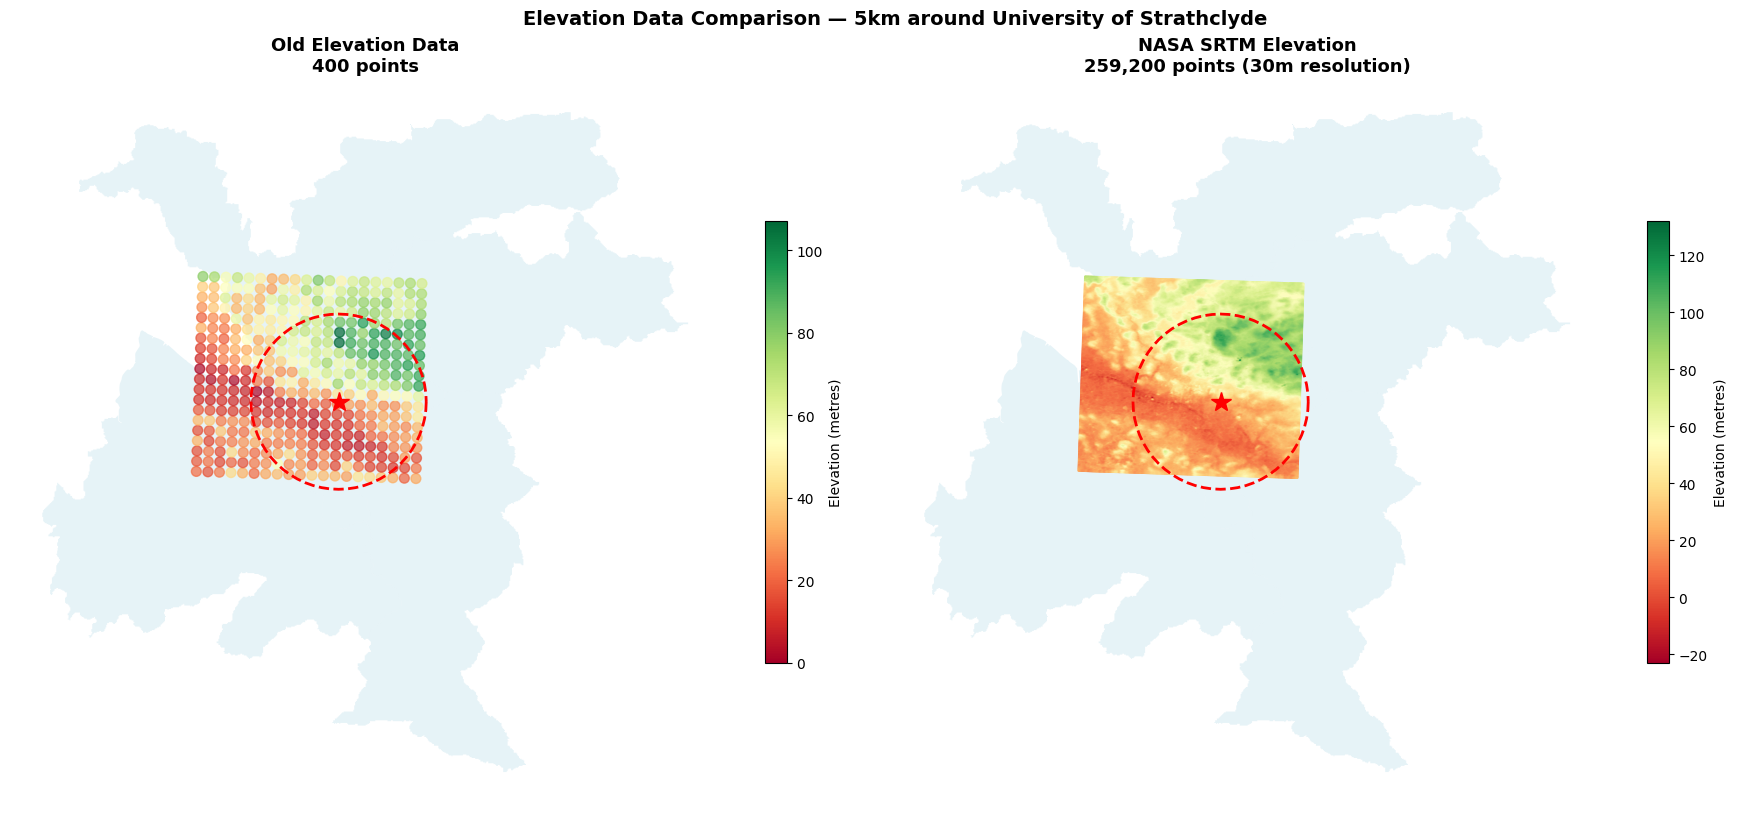

Comparison map saved!


In [5]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import rasterio
from shapely.geometry import Point

# Reload PVA data
pva = gpd.read_file("/Users/riteshghorpade/Documents/010_Project/002_Dataset/GeoPackage/Data/PVAv2.gpkg")
uni_point = Point(260983, 665006)
pva_glasgow = pva[pva.geometry.intersects(uni_point.buffer(5000))]
uni_buffer = gpd.GeoDataFrame(geometry=[uni_point.buffer(5000)], crs="EPSG:27700")

# Load NASA elevation
nasa_gdf = gpd.read_file("/Users/riteshghorpade/Documents/010_Project/002_Dataset/nasa_elevation_glasgow.gpkg")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left - Old elevation (400 points)
old_elev = gpd.read_file("/Users/riteshghorpade/Documents/010_Project/002_Dataset/glasgow_elevation.gpkg")
pva_glasgow.plot(ax=axes[0], color='lightblue', alpha=0.3)
old_elev.plot(ax=axes[0], column='elevation', cmap='RdYlGn',
              markersize=50, alpha=0.7, legend=True,
              legend_kwds={'label': 'Elevation (metres)', 'shrink': 0.6})
uni_buffer.plot(ax=axes[0], color='none', edgecolor='red', linewidth=2, linestyle='--')
axes[0].plot(260983, 665006, marker='*', color='red', markersize=15)
axes[0].set_title("Old Elevation Data\n400 points", fontsize=13, fontweight='bold')
axes[0].axis('off')

# Right - NASA SRTM (259,200 points)
pva_glasgow.plot(ax=axes[1], color='lightblue', alpha=0.3)
nasa_gdf.plot(ax=axes[1], column='elevation', cmap='RdYlGn',
              markersize=0.1, alpha=0.7, legend=True,
              legend_kwds={'label': 'Elevation (metres)', 'shrink': 0.6})
uni_buffer.plot(ax=axes[1], color='none', edgecolor='red', linewidth=2, linestyle='--')
axes[1].plot(260983, 665006, marker='*', color='red', markersize=15)
axes[1].set_title("NASA SRTM Elevation\n259,200 points (30m resolution)", 
                  fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle("Elevation Data Comparison — 5km around University of Strathclyde",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("/Users/riteshghorpade/Documents/010_Project/002_Dataset/elevation_comparison.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("Comparison map saved!")

In [6]:
import requests
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point

print("Downloading NASA GPM Rainfall data for Glasgow...")

# Grid of points covering our 5km study area
lats = np.linspace(55.82, 55.92, 20)
lons = np.linspace(-4.35, -4.15, 20)

# NASA POWER API - provides NASA GPM rainfall data
# No login required
base_url = "https://power.larc.nasa.gov/api/temporal/climatology/point"

rainfall_records = []

for lat in lats:
    for lon in lons:
        params = {
            "parameters": "PRECTOTCORR",  # NASA GPM rainfall
            "community": "RE",
            "longitude": lon,
            "latitude": lat,
            "format": "JSON"
        }
        
        response = requests.get(base_url, params=params)
        
        if response.status_code == 200:
            data = response.json()
            ann_rainfall = data['properties']['parameter']['PRECTOTCORR']['ANN']
            rainfall_records.append({
                'latitude': lat,
                'longitude': lon,
                'annual_rainfall_mm': ann_rainfall
            })

print(f"Rainfall records collected: {len(rainfall_records)}")
print(f"Sample: {rainfall_records[0]}")

Rainfall records collected: 400
Sample: {'latitude': np.float64(55.82), 'longitude': np.float64(-4.35), 'annual_rainfall_mm': 3.78}


Rainfall Stats:
Min rainfall: 3.78 mm/day
Max rainfall: 3.78 mm/day
Average rainfall: 3.78 mm/day
Rainfall data saved!
   latitude  longitude  annual_rainfall_mm                       geometry
0     55.82  -4.350000                3.78  POINT (252864.402 661026.252)
1     55.82  -4.339474                3.78  POINT (253523.769 661003.914)
2     55.82  -4.328947                3.78  POINT (254183.138 660981.676)
3     55.82  -4.318421                3.78  POINT (254842.509 660959.539)
4     55.82  -4.307895                3.78  POINT (255501.882 660937.502)


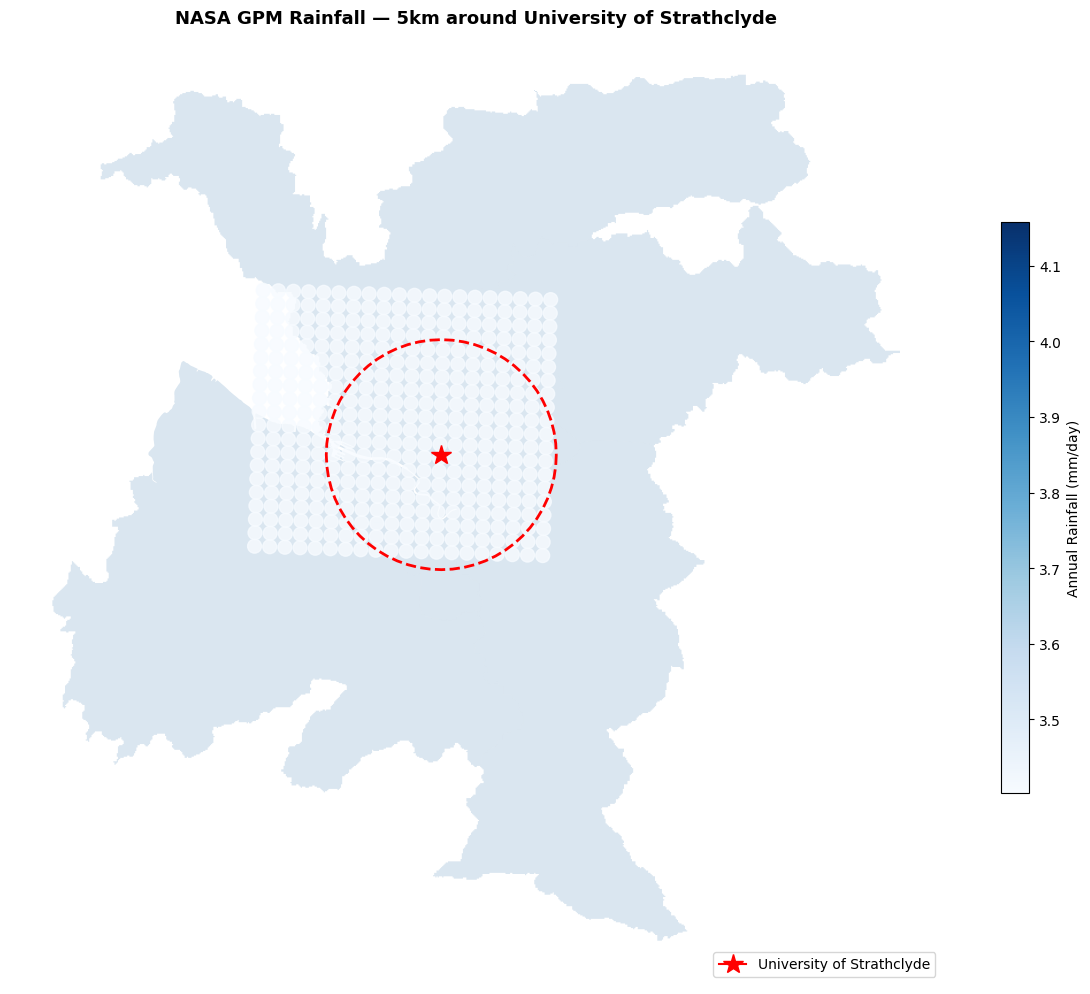

Rainfall map saved!


In [7]:
# Convert to GeoDataFrame
rainfall_df = pd.DataFrame(rainfall_records)

print("Rainfall Stats:")
print("Min rainfall:", rainfall_df['annual_rainfall_mm'].min(), "mm/day")
print("Max rainfall:", rainfall_df['annual_rainfall_mm'].max(), "mm/day")
print("Average rainfall:", round(rainfall_df['annual_rainfall_mm'].mean(), 2), "mm/day")

# Convert to GeoDataFrame
rainfall_gdf = gpd.GeoDataFrame(
    rainfall_df,
    geometry=gpd.points_from_xy(rainfall_df.longitude, rainfall_df.latitude),
    crs="EPSG:4326"
)

# Convert to EPSG:27700 to match other datasets
rainfall_gdf = rainfall_gdf.to_crs("EPSG:27700")

# Save
rainfall_gdf.to_file(
    "/Users/riteshghorpade/Documents/010_Project/002_Dataset/nasa_rainfall_glasgow.gpkg",
    driver="GPKG"
)
print("Rainfall data saved!")
print(rainfall_gdf.head())

# Plot
import matplotlib.pyplot as plt

pva = gpd.read_file("/Users/riteshghorpade/Documents/010_Project/002_Dataset/GeoPackage/Data/PVAv2.gpkg")
uni_point = Point(260983, 665006)
pva_glasgow = pva[pva.geometry.intersects(uni_point.buffer(5000))]
uni_buffer = gpd.GeoDataFrame(geometry=[uni_point.buffer(5000)], crs="EPSG:27700")

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot flood zones
pva_glasgow.plot(ax=ax, color='steelblue', alpha=0.2)

# Plot rainfall
rainfall_gdf.plot(
    ax=ax,
    column='annual_rainfall_mm',
    cmap='Blues',
    markersize=100,
    alpha=0.8,
    legend=True,
    legend_kwds={'label': 'Annual Rainfall (mm/day)', 'shrink': 0.6}
)

# Study area boundary
uni_buffer.plot(ax=ax, color='none', edgecolor='red', linewidth=2, linestyle='--')

# University point
ax.plot(260983, 665006, marker='*', color='red', markersize=15, label='University of Strathclyde')

ax.set_title("NASA GPM Rainfall — 5km around University of Strathclyde",
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("/Users/riteshghorpade/Documents/010_Project/002_Dataset/nasa_rainfall_map.png", dpi=150)
plt.show()
print("Rainfall map saved!")

In [8]:
import requests
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point

print("Downloading NASA GPM Monthly Rainfall data for Glasgow...")

# Smaller grid - 10x10 = 100 points to keep it fast
lats = np.linspace(55.82, 55.92, 10)
lons = np.linspace(-4.35, -4.15, 10)

base_url = "https://power.larc.nasa.gov/api/temporal/climatology/point"

monthly_records = []
total = len(lats) * len(lons)
count = 0

for lat in lats:
    for lon in lons:
        params = {
            "parameters": "PRECTOTCORR",
            "community": "RE",
            "longitude": lon,
            "latitude": lat,
            "format": "JSON"
        }
        
        response = requests.get(base_url, params=params)
        
        if response.status_code == 200:
            data = response.json()
            monthly = data['properties']['parameter']['PRECTOTCORR']
            
            record = {
                'latitude': lat,
                'longitude': lon,
                'rainfall_jan': monthly['JAN'],
                'rainfall_feb': monthly['FEB'],
                'rainfall_mar': monthly['MAR'],
                'rainfall_apr': monthly['APR'],
                'rainfall_may': monthly['MAY'],
                'rainfall_jun': monthly['JUN'],
                'rainfall_jul': monthly['JUL'],
                'rainfall_aug': monthly['AUG'],
                'rainfall_sep': monthly['SEP'],
                'rainfall_oct': monthly['OCT'],
                'rainfall_nov': monthly['NOV'],
                'rainfall_dec': monthly['DEC'],
                'rainfall_annual': monthly['ANN']
            }
            monthly_records.append(record)
        
        count += 1
        if count % 10 == 0:
            print(f"Progress: {count}/{total} points done")

print(f"\nTotal records collected: {len(monthly_records)}")
print(f"Sample record: {monthly_records[0]}")

Progress: 10/100 points done
Progress: 20/100 points done
Progress: 30/100 points done
Progress: 40/100 points done
Progress: 50/100 points done
Progress: 60/100 points done
Progress: 70/100 points done
Progress: 80/100 points done
Progress: 90/100 points done
Progress: 100/100 points done

Total records collected: 100
Sample record: {'latitude': np.float64(55.82), 'longitude': np.float64(-4.35), 'rainfall_jan': 4.42, 'rainfall_feb': 3.62, 'rainfall_mar': 3.04, 'rainfall_apr': 2.52, 'rainfall_may': 2.98, 'rainfall_jun': 3.54, 'rainfall_jul': 3.92, 'rainfall_aug': 4.42, 'rainfall_sep': 3.53, 'rainfall_oct': 4.61, 'rainfall_nov': 4.45, 'rainfall_dec': 4.24, 'rainfall_annual': 3.78}


Monthly Rainfall Stats:
       rainfall_jan  rainfall_apr  rainfall_jul  rainfall_oct  rainfall_annual
count        100.00        100.00        100.00        100.00           100.00
mean           4.42          2.52          3.92          4.61             3.78
std            0.00          0.00          0.00          0.00             0.00
min            4.42          2.52          3.92          4.61             3.78
25%            4.42          2.52          3.92          4.61             3.78
50%            4.42          2.52          3.92          4.61             3.78
75%            4.42          2.52          3.92          4.61             3.78
max            4.42          2.52          3.92          4.61             3.78

Monthly rainfall data saved!


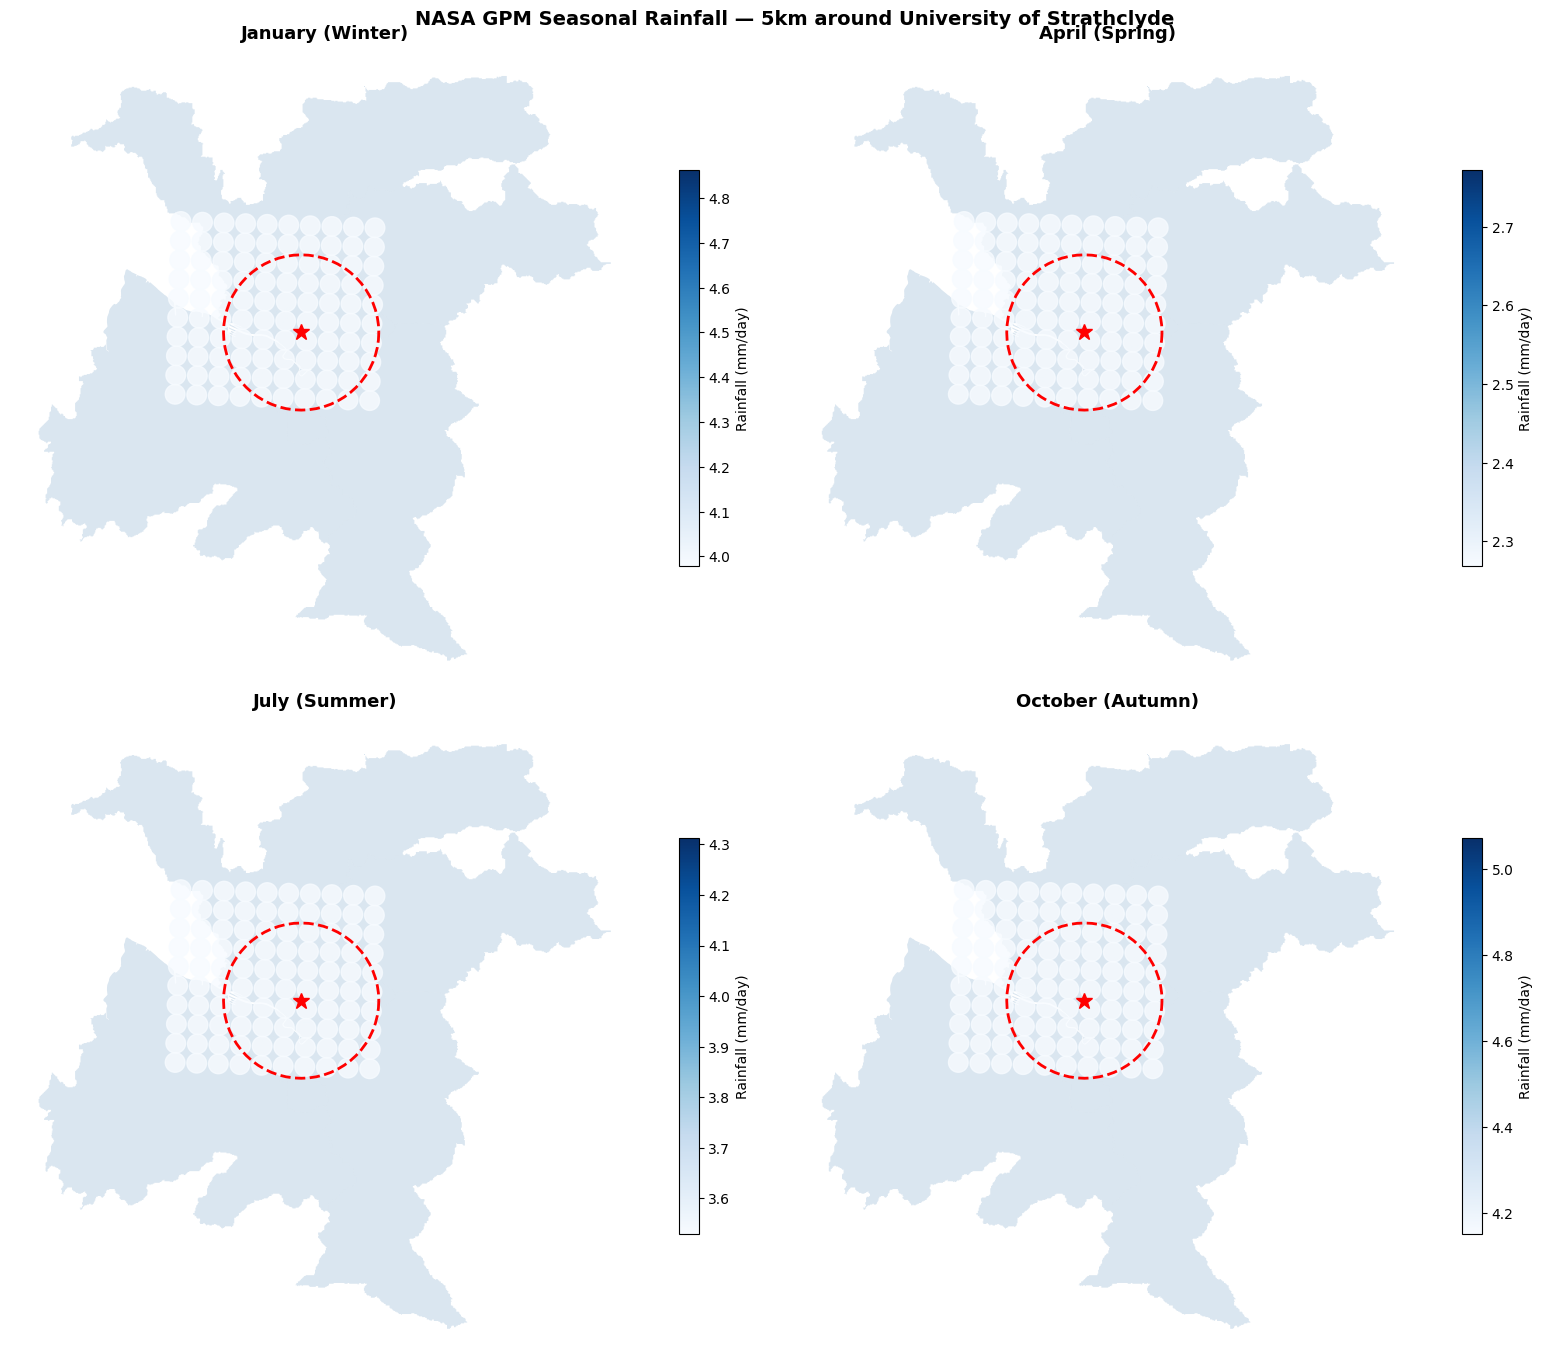

Seasonal rainfall map saved!


In [9]:
# Convert to GeoDataFrame
rainfall_df = pd.DataFrame(monthly_records)

print("Monthly Rainfall Stats:")
print(rainfall_df[['rainfall_jan','rainfall_apr','rainfall_jul','rainfall_oct','rainfall_annual']].describe().round(2))

# Convert to GeoDataFrame
rainfall_gdf = gpd.GeoDataFrame(
    rainfall_df,
    geometry=gpd.points_from_xy(rainfall_df.longitude, rainfall_df.latitude),
    crs="EPSG:4326"
)

# Convert to EPSG:27700
rainfall_gdf = rainfall_gdf.to_crs("EPSG:27700")

# Save
rainfall_gdf.to_file(
    "/Users/riteshghorpade/Documents/010_Project/002_Dataset/nasa_rainfall_monthly_glasgow.gpkg",
    driver="GPKG"
)
print("\nMonthly rainfall data saved!")

# Plot seasonal comparison
import matplotlib.pyplot as plt

pva = gpd.read_file("/Users/riteshghorpade/Documents/010_Project/002_Dataset/GeoPackage/Data/PVAv2.gpkg")
uni_point = Point(260983, 665006)
pva_glasgow = pva[pva.geometry.intersects(uni_point.buffer(5000))]
uni_buffer = gpd.GeoDataFrame(geometry=[uni_point.buffer(5000)], crs="EPSG:27700")

# Plot 4 seasons
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

seasons = [
    ('rainfall_jan', 'January (Winter)', axes[0,0]),
    ('rainfall_apr', 'April (Spring)', axes[0,1]),
    ('rainfall_jul', 'July (Summer)', axes[1,0]),
    ('rainfall_oct', 'October (Autumn)', axes[1,1])
]

for col, title, ax in seasons:
    pva_glasgow.plot(ax=ax, color='steelblue', alpha=0.2)
    rainfall_gdf.plot(
        ax=ax,
        column=col,
        cmap='Blues',
        markersize=200,
        alpha=0.8,
        legend=True,
        legend_kwds={'label': 'Rainfall (mm/day)', 'shrink': 0.6}
    )
    uni_buffer.plot(ax=ax, color='none', edgecolor='red', linewidth=2, linestyle='--')
    ax.plot(260983, 665006, marker='*', color='red', markersize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle("NASA GPM Seasonal Rainfall — 5km around University of Strathclyde",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/Users/riteshghorpade/Documents/010_Project/002_Dataset/nasa_rainfall_seasonal_map.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("Seasonal rainfall map saved!")